In [15]:
#!/usr/bin/python3
import sys
import os

sys.path.append(os.path.abspath(".."))

import pickle
import Scripts.utils
from Scripts.utils import *
import numpy as np
from numpy import array
import glob
import pandas as pd
import matplotlib.pyplot as plt
import random, math
import matplotlib.ticker as ticker
import seaborn as sns
from rich.console import Console
from rich.table import Table
from matplotlib.colors import ListedColormap
from sklearn.model_selection import KFold
from tensorflow.keras.utils import plot_model
import visualkeras
from PIL import ImageFont, Image
from sklearn.metrics import r2_score

import copy
import random, math
import time
from joblib import dump
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error as mse
from tensorflow.keras.metrics import RootMeanSquaredError as rmse

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

np.seterr(divide='ignore', invalid='ignore')

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

dataSamplesGev = np.load('../Data/lzt_dictClus7x7_99k_SignalsSamples_e50_GeV.pkl', allow_pickle=True)
dataAmplitudeGev = np.load('../Data/lzt_dictClus7x7_99k_Amplitudes_e50_GeV.pkl', allow_pickle=True)

# Leitura de elementos do sinal do vetor de amostras
EtruthSampGeV = dataSamplesGev['E'] 
XTcSampGeV = dataSamplesGev['XT_C']
XTlSampGeV = dataSamplesGev['XT_L']
XTrSampGeV = dataSamplesGev['XT_R']
NoiseSampGeV = dataSamplesGev['Noise']

# Sinal de leitura de energia somado as contribuições de Crosstalk e ruído
xDataSamplesGeV = np.add(np.add(np.add(np.add(EtruthSampGeV, XTcSampGeV), XTlSampGeV), NoiseSampGeV), XTrSampGeV)

# Leitura de elementos do sinal do vetor de amplitudes
EtruthAmpGeV = dataAmplitudeGev['E']
XTcAmpGeV = dataAmplitudeGev['XT_C']
XTlAmpGeV = dataAmplitudeGev['XT_L']
XTrAmpGeV = dataAmplitudeGev['XT_R']
NoiseAmpGeV = dataAmplitudeGev['Noise']

# Sinal de leitura de energia somado as contribuições de Crosstalk e ruído
xDataAmpGeV = np.add(np.add(np.add(np.add(EtruthAmpGeV, XTcAmpGeV), XTlAmpGeV), NoiseAmpGeV), XTrAmpGeV)

AmpTimeGeV  = OptFilt(EtruthSampGeV)
AmpTimeXTGeV  = OptFilt(xDataSamplesGeV)

AmplitudesGeVOptFilt = AmpTimeGeV['Clusters']['Amplitude']
XTAmplitudesGeVOptFilt = AmpTimeXTGeV['Clusters']['Amplitude']

shape_val = xDataSamplesGeV.shape[0]

TimesGeVOptFilt = AmpTimeGeV['Clusters']['Time']
XT_Times_Optfilt = AmpTimeXTGeV['Clusters']['Time']

scaler_data_amp = MinMaxScaler()
scaler_etruth = MinMaxScaler()
scaler_time = MinMaxScaler()
scaler_samp = MinMaxScaler()
scaler_data_samp = MinMaxScaler()
xDataAmpGeV_Normalized = scaler_data_amp.fit_transform(xDataAmpGeV)
EtruthAmpGeV_Normalized = scaler_etruth.fit_transform(EtruthAmpGeV)
TimesGeVOptFilt_Normalized = scaler_time.fit_transform(TimesGeVOptFilt)

toGeV = 1000
xDataSampGeV_Normalized = scaler_data_samp.fit_transform(xDataSamplesGeV)
EtruthSampGeV_Normalized = scaler_samp.fit_transform(EtruthSampGeV)

toGeV = 1000

ij_cell = ['-3,3' , '-2,3' , '-1,3' , '0,3' , '1,3' , '2,3' , '3,3' , 
           '-3,2' , '-2,2' , '-1,2' , '0,2' , '1,2' , '2,2' , '3,2' , 
           '-3,1' , '-2,1' , '-1,1' , '0,1' , '1,1' , '2,1' , '3,1' , 
           '-3,0' , '-2,0' , '-1,0' , '0,0' , '1,0' , '2,0' , '3,0' , 
           '-3,-1', '-2,-1', '-1,-1', '0,-1', '1,-1', '2,-1', '3,-1', 
           '-3,-2', '-2,-2', '-1,-2', '0,-2', '1,-2', '2,-2', '3,-2', 
           '-3,-3', '-2,-3', '-1,-3', '0,-3', '1,-3', '2,-3', '3,-3' ]

Scaled_EtruthSampGeV = EtruthSampGeV.astype('float32')/toGeV
Scaled_xDataSampGeV_Normalized = xDataSampGeV_Normalized.astype('float32')/toGeV

E_truth_energy_toConv = Scaled_EtruthSampGeV.reshape(shape_val * 4, 7, 7, 1)
XTData_denoise_toConv = xDataSampGeV_Normalized.reshape(shape_val * 4, 7, 7, 1)

Num GPUs Available:  1


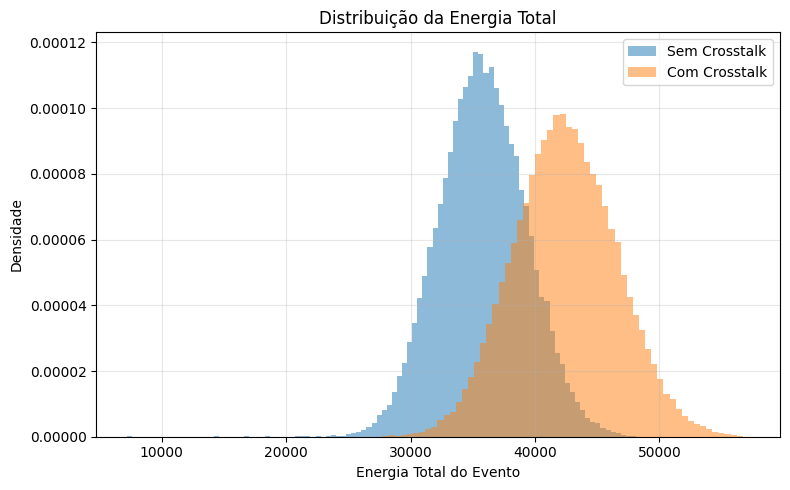

In [4]:
energia_total_sem_ct = np.sum(AmplitudesGeVOptFilt, axis=1)
energia_total_com_ct = np.sum(XTAmplitudesGeVOptFilt, axis=1)

plt.figure(figsize=(8,5))

plt.hist(
    energia_total_sem_ct,
    bins=100,
    alpha=0.5,
    density=True,
    label='Sem Crosstalk'
)

plt.hist(
    energia_total_com_ct,
    bins=100,
    alpha=0.5,
    density=True,
    label='Com Crosstalk'
)

plt.xlabel('Energia Total do Evento')
plt.ylabel('Densidade')
plt.title('Distribuição da Energia Total')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

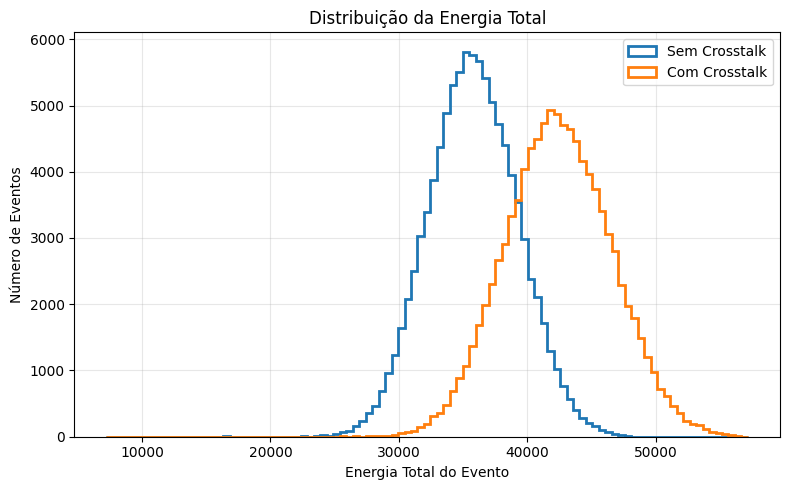

In [5]:
energia_total_sem_ct = AmplitudesGeVOptFilt.sum(axis=1)
energia_total_com_ct = XTAmplitudesGeVOptFilt.sum(axis=1)

bins = np.linspace(
    min(energia_total_sem_ct.min(), energia_total_com_ct.min()),
    max(energia_total_sem_ct.max(), energia_total_com_ct.max()),
    100
)

plt.figure(figsize=(8,5))

plt.hist(
    energia_total_sem_ct,
    bins=bins,
    histtype='step',
    linewidth=2,
    label='Sem Crosstalk'
)

plt.hist(
    energia_total_com_ct,
    bins=bins,
    histtype='step',
    linewidth=2,
    label='Com Crosstalk'
)

plt.xlabel('Energia Total do Evento')
plt.ylabel('Número de Eventos')
plt.title('Distribuição da Energia Total')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

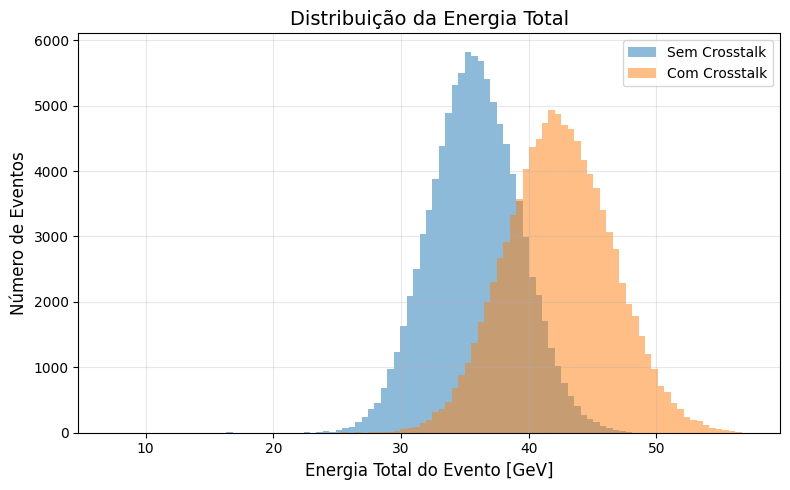

In [14]:
energia_total_sem_ct = AmplitudesGeVOptFilt.sum(axis=1)/1000
energia_total_com_ct = XTAmplitudesGeVOptFilt.sum(axis=1)/1000

bins = np.linspace(
    min(energia_total_sem_ct.min(), energia_total_com_ct.min()),
    max(energia_total_sem_ct.max(), energia_total_com_ct.max()),
    100
)

plt.figure(figsize=(8,5))

plt.hist(
    energia_total_sem_ct,
    bins=bins,
    alpha=0.5,
    label='Sem Crosstalk'
)

plt.hist(
    energia_total_com_ct,
    bins=bins,
    alpha=0.5,
    label='Com Crosstalk'
)

plt.xlabel('Energia Total do Evento [GeV]', fontsize=12)
plt.ylabel('Número de Eventos', fontsize=12)
plt.title('Distribuição da Energia Total', fontsize=14)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

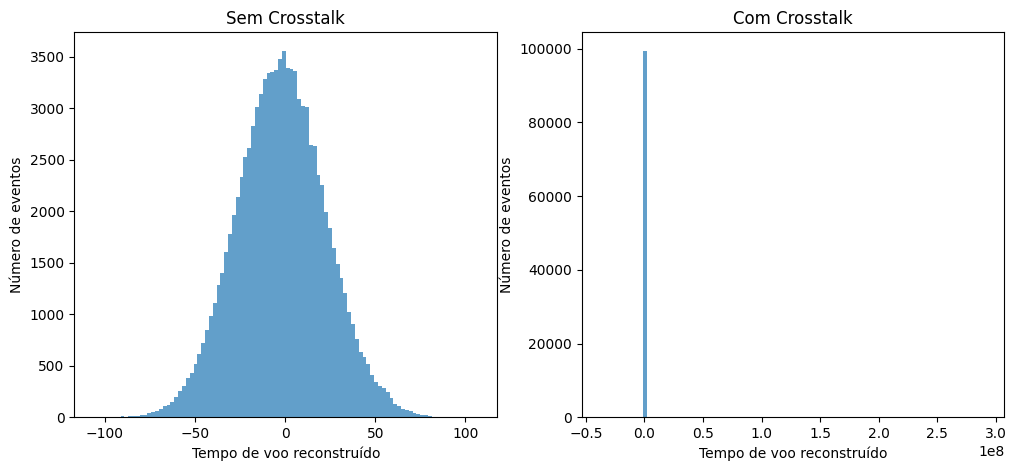

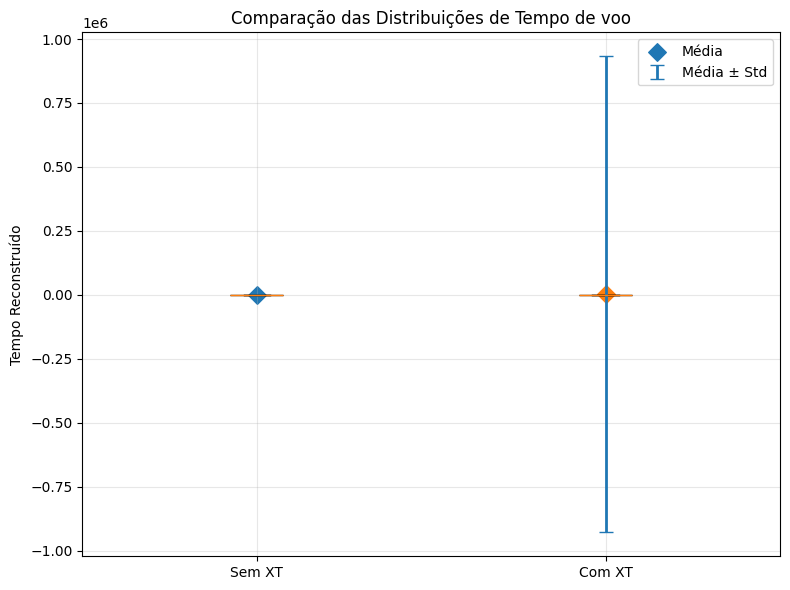

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].hist(energia_total_sem_ct, bins=100, alpha=0.7)
ax[0].set_title('Sem Crosstalk')
ax[0].set_xlabel('Tempo de voo reconstruído')
ax[0].set_ylabel('Número de eventos')

ax[1].hist(energia_total_com_ct, bins=100, alpha=0.7)
ax[1].set_title('Com Crosstalk')
ax[1].set_xlabel('Tempo de voo reconstruído')
ax[1].set_ylabel('Número de eventos')

datasets = [energia_total_sem_ct, energia_total_com_ct]
labels = ['Sem XT', 'Com XT']

fig, ax = plt.subplots(figsize=(8,6))

# Boxplot
bp = ax.boxplot(
    datasets,
    tick_labels=labels,
    showfliers=False,
    patch_artist=True
)

# Estatísticas adicionais
for i, x in enumerate(datasets, start=1):

    media = np.mean(x)
    mediana = np.median(x)
    std = np.std(x)

    # Média
    ax.scatter(
        i,
        media,
        marker='D',
        s=80,
        label='Média' if i == 1 else ""
    )

    # Média ± std
    ax.errorbar(
        i,
        media,
        yerr=std,
        fmt='none',
        capsize=5,
        linewidth=2,
        label='Média ± Std' if i == 1 else ""
    )

ax.set_ylabel('Tempo Reconstruído')
ax.set_title('Comparação das Distribuições de Tempo de voo')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()